In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,ConfusionMatrixDisplay,roc_auc_score,roc_curve
import matplotlib.pyplot as plt

# Loading the dataset

In [21]:
credit_df = pd.read_csv("german_credit_data.csv")
credit_df.head(15)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
5,35,male,1,free,NaN,NaN,9055,36,education,good
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,35,male,3,rent,little,moderate,6948,36,car,good
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,28,male,3,own,little,moderate,5234,30,car,bad


# Handling the missing values

In [22]:
credit_df = credit_df.fillna("none")

# Encoding the target variable

In [23]:
label_enc = LabelEncoder()
credit_df["risk_encoded"] = label_enc.fit_transform(credit_df["Risk"])
credit_df.drop(columns="Risk",inplace=True)

In [24]:
X = credit_df.drop("risk_encoded",axis=1)
y = credit_df["risk_encoded"]

# Encoding the input features

In [25]:
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()
numeric_features = X.select_dtypes(include=["number"]).columns.to_list()
if "Job" in numeric_features:
    numeric_features.remove("Job")
print(numeric_features)


['Age', 'Credit amount', 'Duration']


# Dividing the categorical features into nominal and ordinal features

In [26]:
ordinal_features = ["Saving accounts","Checking account","Job"]
nominal_features = [col for col in categorical_features if col not in ordinal_features]
print(ordinal_features,nominal_features)

['Saving accounts', 'Checking account', 'Job'] ['Sex', 'Housing', 'Purpose']


# Defining the order of the categories

In [27]:
saving_order = ["none","little","moderate","quite rich","rich"]
checking_order = ["none","little","moderate","rich"]
job_order = [0,1,2,3]

explicit_cat = [saving_order,checking_order,job_order]

preprocessor = ColumnTransformer(
    transformers=[("num","passthrough",numeric_features),
                  ("ord",OrdinalEncoder(categories=explicit_cat,handle_unknown="use_encoded_value",unknown_value=-1),ordinal_features),
                  ("nom",OneHotEncoder(handle_unknown="ignore"),nominal_features)]
)

# Splitting the dataset into training and testing sets

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [29]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded,columns=feature_names)
X_train_df.head()

,num__Age,num__Credit amount,num__Duration,ord__Saving accounts,ord__Checking account,ord__Job,nom__Sex_female,nom__Sex_male,nom__Housing_free,nom__Housing_own,nom__Housing_rent,nom__Purpose_business,nom__Purpose_car,nom__Purpose_domestic appliances,nom__Purpose_education,nom__Purpose_furniture/equipment,nom__Purpose_radio/TV,nom__Purpose_repairs,nom__Purpose_vacation/others
0,26.0,4530.0,30.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,41.0,2503.0,30.0,2.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,22.0,1567.0,12.0,1.0,2.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,35.0,3976.0,21.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,22.0,2301.0,9.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Performing feature selection from the encoded features

In [30]:
baseline_rf = RandomForestClassifier(n_estimators=50,random_state=42,class_weight="balanced")
selector = SelectFromModel(baseline_rf,threshold="median")
X_train_selected = selector.fit_transform(X_train_encoded,y_train)
X_test_selected = selector.transform(X_test_encoded)
print(f"Training dataset shape:{X_train_selected.shape}")
print(f"Test data set shape: {X_test_selected.shape}")

Training dataset shape:(800, 10)
Test data set shape: (200, 10)


In [31]:
selected_features = feature_names[selector.get_support()]
print(selected_features)

['num__Age' 'num__Credit amount' 'num__Duration' 'ord__Saving accounts'
 'ord__Checking account' 'ord__Job' 'nom__Sex_female' 'nom__Housing_own'
 'nom__Purpose_car' 'nom__Purpose_radio/TV']


In [32]:
final_rf = RandomForestClassifier(n_estimators=50,random_state=42,class_weight="balanced")
final_rf.fit(X_train_selected,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1

# Evaluating the model on the test dataset

In [33]:
y_pred = final_rf.predict(X_test_selected)
print(y_pred)

[1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 0 0
 1 1 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 0 1 0
 1 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 0 1 1
 1 1 1 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 1 0 0 1
 1 0 0 0 1 1 1 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 1 0 0 1 1 0 0 1 1 0 1
 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1]


# Creating the confusion matrix

In [34]:
conf_mat = confusion_matrix(y_test,y_pred)
print(conf_mat)

[[ 37  23]
 [ 34 106]]


# Plotting the confusion matrix

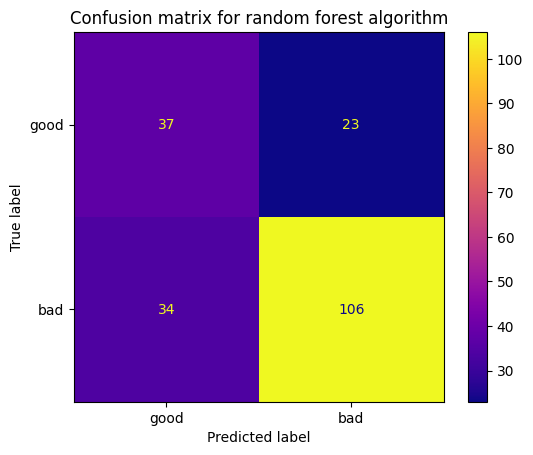

In [35]:
disp = ConfusionMatrixDisplay(conf_mat,display_labels=["good","bad"])
disp.plot(cmap=plt.cm.plasma)
plt.title("Confusion matrix for random forest algorithm")
plt.show()

In [36]:
y_probs = final_rf.predict_proba(X_test_selected)[:,1]
model_accuracy = accuracy_score(y_test,y_pred)
auc_score = roc_auc_score(y_test,y_probs)
print("Accuracy: ",model_accuracy)
print("ROC - AUC score",auc_score)

Accuracy:  0.715
ROC - AUC score 0.7557738095238095


# Plotting the `ROC` curve

In [37]:
fpr,tpr,thresholds = roc_curve(y_test,y_probs)

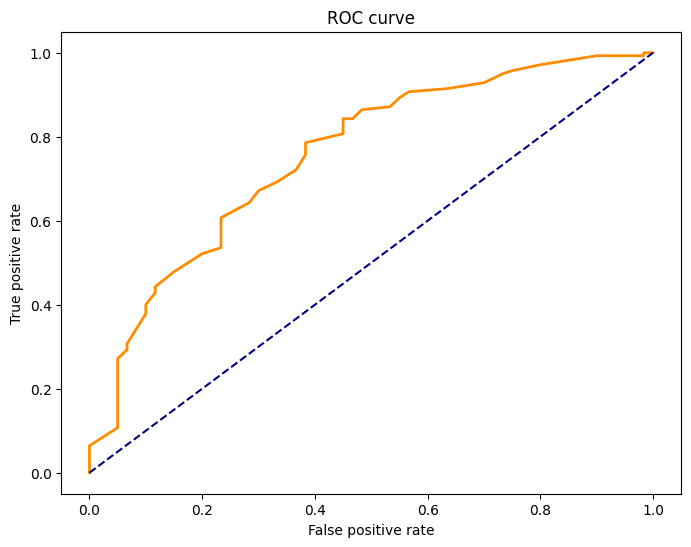

In [38]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color="darkorange",linewidth=2,label=f"Random forest (AUC = {auc_score:.3f})")
plt.plot([0,1],[0,1],color="navy",linestyle="dashed",label=f"Random gues (AUC: 0.5)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.show()